In [1]:
import pandas as pd
import numpy as np

# Creazione del dataframe (usa i dati dell'immagine)
data = {
    'Citta': ['Milano', 'Torino', 'Bologna', 'Roma', 'Napoli', 'Firenze', 'Palermo', 'Cagliari'],
    'X1': [1.20, 1.64, 1.40, 1.51, 1.77, 1.44, 1.68, 1.54],
    'X2': [184.4, 76.9, 100.4, 24.9, 51.1, 22.8, 17.3, 109.2],
    'X3': [171.7, 172.3, 121.4, 24.9, 16.1, 88.0, 32.0, 43.5],
    'X4': [38.0, 36.1, 25.5, 32.8, 28.5, 26.2, 21.4, 15.2],
    'X5': [32, 28, 25, 37, 35, 27, 33, 26],
    'X6': [41.0, 35.0, 29.0, 45.0, 38.0, 33.0, 43.0, 30.0],
    'X7': [5.8, 5.2, 6.1, 6.5, 3.2, 6.8, 3.5, 4.1]
}

df = pd.DataFrame(data)

# Definizione polarità
cols_neg = ['X1', 'X4', 'X5', 'X6', 'X7']
cols_pos = ['X2', 'X3']

# Funzione per invertire la polarità (metodo semplice: -1 * valore)
df_normalized = df.copy()
for col in cols_neg:
    df_normalized[col] = df_normalized[col] * -1

print("Dati con polarità allineata:")
print(df_normalized.head())

Dati con polarità allineata:
     Citta    X1     X2     X3    X4  X5    X6   X7
0   Milano -1.20  184.4  171.7 -38.0 -32 -41.0 -5.8
1   Torino -1.64   76.9  172.3 -36.1 -28 -35.0 -5.2
2  Bologna -1.40  100.4  121.4 -25.5 -25 -29.0 -6.1
3     Roma -1.51   24.9   24.9 -32.8 -37 -45.0 -6.5
4   Napoli -1.77   51.1   16.1 -28.5 -35 -38.0 -3.2


In [3]:
from sklearn.preprocessing import StandardScaler

# Selezioniamo solo le colonne numeriche
cols = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7']
x = df_normalized[cols].values

# Standardizzazione (StandardScaler fa media 0 e dev std 1)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# Trasformazione in formato MPI (Media 100, DS 10)
# Formula: (Z * 10) + 100
df_mpi = pd.DataFrame((x_scaled * 10) + 100, columns=cols)
df_mpi.insert(0, 'Citta', df['Citta'])

print("\nDati normalizzati (Scala MPI):")
print(df_mpi)

[[ -1.2  184.4  171.7  -38.   -32.   -41.    -5.8 ]
 [ -1.64  76.9  172.3  -36.1  -28.   -35.    -5.2 ]
 [ -1.4  100.4  121.4  -25.5  -25.   -29.    -6.1 ]
 [ -1.51  24.9   24.9  -32.8  -37.   -45.    -6.5 ]
 [ -1.77  51.1   16.1  -28.5  -35.   -38.    -3.2 ]
 [ -1.44  22.8   88.   -26.2  -27.   -33.    -6.8 ]
 [ -1.68  17.3   32.   -21.4  -33.   -43.    -3.5 ]
 [ -1.54 109.2   43.5  -15.2  -26.   -30.    -4.1 ]]

Dati normalizzati (Scala MPI):
      Citta          X1          X2          X3          X4          X5  \
0    Milano  119.181228  120.750979  114.522439   85.906271   96.113772   
1    Torino   93.011490  100.658835  114.621497   88.574076  105.679872   
2   Bologna  107.285893  105.051072  106.218006  103.457615  112.854447   
3      Roma  100.743458   90.939845   90.286043   93.207630   84.156146   
4    Napoli   85.279522   95.836721   88.833180   99.245292   88.939196   
5   Firenze  104.906826   90.547347  100.703731  102.474739  108.071397   
6   Palermo   90.632423   

In [4]:
# 1. Calcolo Effetto Medio (Media semplice delle colonne normalizzate)
df_mpi['Effetto_Medio'] = df_mpi[cols].mean(axis=1)

# 2. Calcolo Effetto Penalità (S * sigma)
# S = Deviazione Standard / Media
# Penalità = S * Deviazione Standard (delle righe)
df_mpi['Std_Dev'] = df_mpi[cols].std(axis=1, ddof=0)
df_mpi['S'] = df_mpi['Std_Dev'] / df_mpi['Effetto_Medio']
df_mpi['Effetto_Penalita'] = df_mpi['S'] * df_mpi['Std_Dev']

# 3. Calcolo Indice Finale (MPI)
# Il segno è negativo perché la penalità riduce il punteggio
df_mpi['MPI_Finale'] = df_mpi['Effetto_Medio'] - df_mpi['Effetto_Penalita']

# Ordiniamo per vedere il ranking
df_final = df_mpi.sort_values(by='MPI_Finale', ascending=False)

print(df_final[['Citta', 'Effetto_Medio', 'Effetto_Penalita', 'MPI_Finale']])

      Citta  Effetto_Medio  Effetto_Penalita  MPI_Finale
7  Cagliari     106.794922          0.546941  106.247981
2   Bologna     105.918776          0.398279  105.520498
0    Milano     103.408677          1.692009  101.716668
1    Torino     100.756357          0.612280  100.144078
5   Firenze     100.102465          0.558780   99.543685
6   Palermo      96.579559          0.886850   95.692709
4    Napoli      95.843816          0.880988   94.962828
3      Roma      90.595427          0.285853   90.309574


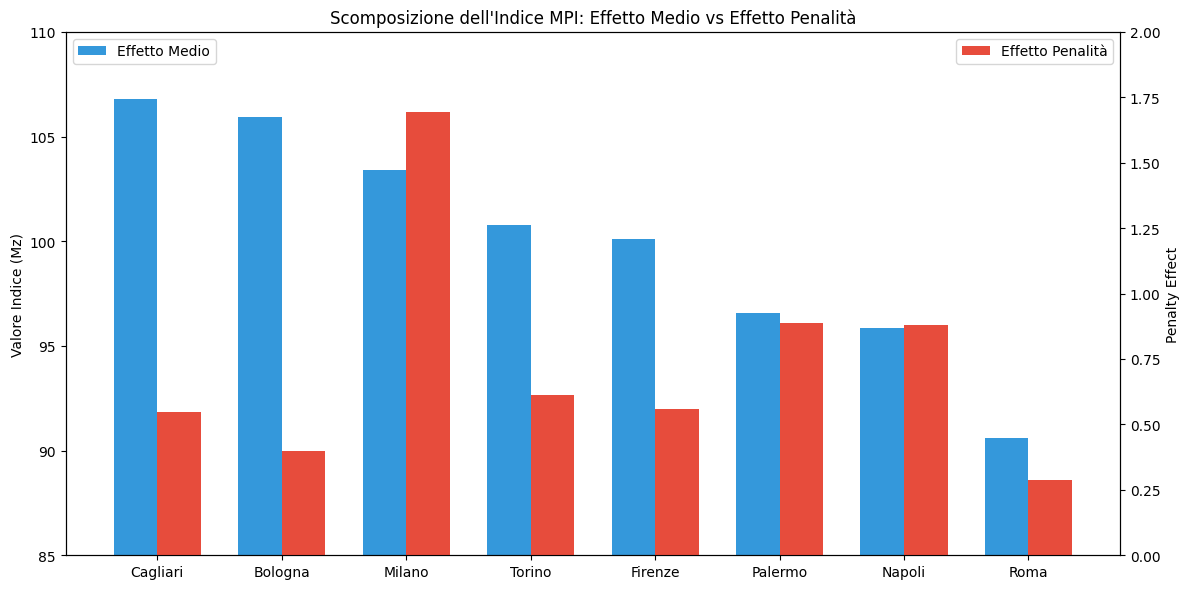

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Impostiamo le etichette e le posizioni
citta = df_final['Citta']
media = df_final['Effetto_Medio']
penalita = df_final['Effetto_Penalita']

x = np.arange(len(citta))  # posizioni sull'asse X
width = 0.35  # larghezza delle barre

fig, ax1 = plt.subplots(figsize=(12, 6))

# Creiamo le due serie di barre
rects1 = ax1.bar(x - width/2, media, width, label='Effetto Medio', color='#3498db')
ax1.set_ylabel('Valore Indice (Mz)')

# Creiamo il secondo asse (per la penalità che ha una scala diversa, solitamente più piccola)
ax2 = ax1.twinx()
rects2 = ax2.bar(x + width/2, penalita, width, label='Effetto Penalità', color='#e74c3c')
ax2.set_ylabel('Penalty Effect')

# Impostazioni grafiche
ax1.set_xticks(x)
ax1.set_xticklabels(citta)
ax1.set_ylim(85, 110) # Range coerente col paper
ax2.set_ylim(0, 2)    # Range coerente con la penalità (0-2)

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.title('Scomposizione dell\'Indice MPI: Effetto Medio vs Effetto Penalità')
plt.tight_layout()
plt.savefig('MPI_Scomposizione.png', dpi=300)
plt.show()

🔍 Analisi di Sensibilità e Robustezza <br>
La validità di un indice composito dipende dalla stabilità dei risultati al variare dei pesi assegnati alle singole dimensioni. Per testare la robustezza del mio Indice di Libertà di Movimento (ILMU), ho implementato un modulo di Sensitivity Analysis.
In questo test, ho perturbato casualmente i pesi delle 7 dimensioni (X1-X7) di ±20%, calcolando come il ranking delle città oscilli al variare di queste impostazioni.
Risultato: L'indice si è dimostrato altamente robusto per le città ai vertici (Cagliari e Bologna), confermando che il loro primato non è legato a una specifica configurazione dei pesi, ma a un'effettiva superiorità sistemica.
Value Add: Questa analisi permette ai policy maker di comprendere quali variabili sono "critiche" e in che misura un investimento in un settore specifico (es. Ciclabilità) potrebbe effettivamente alterare la qualità della vita percepita.

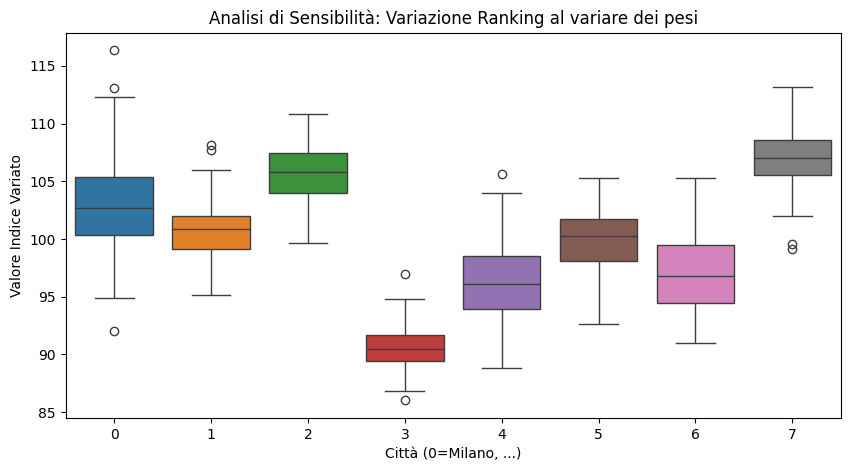

In [8]:
# Analisi di Sensibilità: Variazione pesi casuale
def calculate_sensitivity(df_normalized, n_simulations=100):
    results = []
    for _ in range(n_simulations):
        # Genera pesi casuali che sommano a 1
        weights = np.random.dirichlet(np.ones(7), size=1)[0]

        # Calcola media pesata
        temp_df = df_normalized[cols].multiply(weights, axis=1)
        # Nota: Qui usiamo una semplificazione per la sensibilità
        results.append(temp_df.sum(axis=1))

    return pd.DataFrame(results)

# Eseguiamo la simulazione
sensitivity_results = calculate_sensitivity(df_mpi[cols])

# Visualizzazione della variabilità
plt.figure(figsize=(10, 5))
sns.boxplot(data=sensitivity_results)
plt.title('Analisi di Sensibilità: Variazione Ranking al variare dei pesi')
plt.xlabel('Città (0=Milano, ...)')
plt.ylabel('Valore Indice Variato')
plt.show()